In [118]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, confusion_matrix,
    roc_auc_score, precision_score, recall_score
)
import warnings
warnings.filterwarnings('ignore')

In [119]:
TRAIN_PATH  = 'data/train_data_fixed.csv'
TEST_PATH   = 'data/test.csv'
OUTPUT_PATH = 'submission.csv'

THRESHOLD   = 0.450   # оптимальний f1 трешхолд (шукала обхідними путями)
SMOOTHING   = 10      # target encoding smoothing factor
MIN_SAMPLES = 50      # min group size for target encoding

In [120]:
FEATURES = [
    # Raw numeric
    'amount_scaled',             # transaction amount (normalized)
    'card_exp_relative_scaled',  # card expiry proximity

    # Temporal
    'hour_of_day',               # hour of transaction (0-23)
    'dayofweek',                 # day of week (0=Mon, 6=Sun)

    # Label encoded categoricals
    'merchant_token_type_enc',   # recurring / rebill / 1-click
    'token_type_enc',            # network_token / bank_token / card_data
    'transaction_type_enc',      # first / token / resign
    'card_pan_type_enc',         # pan / dpan (device token)
    'platform_enc',              # WEB / MOB / APP (normalized to uppercase)

    # Target encoded: single key
    'shop_ar_hist',              # merchant approval rate history
    'mcc_ar_hist',               # business category approval rate
    'card_country_ar',           # card country approval rate
    'ip_country_ar',             # IP country approval rate
    'bank_ar',                   # issuer bank approval rate

    # Target encoded: composite key
    'acquirer_card_combo_ar',    # acquirer x cardbrand x cardtype
    'shop_acq_ar',               # merchant x acquirer
    'shop_payment_ar',           # merchant x payment source
    'mcc_cardtype_ar',           # business category x card type
    'card_ip_combo_ar',          # card country x ip country (geo mismatch)
    'token_payment_ar',          # merchant_token_type x payment_source
    'bank_acq_ar',               # issuer bank x acquirer

    # Interaction feature
    'cascade_x_acquirer_ar',     # cascade_number x acquirer AR

    # Customer behavior
    'customer_freq',             # how many times this customer appears in train

    # Temporal user behavior (computed on train+test concat)
    'psp_prev_hour_volume',      # PSP transaction load in previous hour
    'user_prev_tx_count',        # number of previous transactions by this user
    'user_time_since_prev_tx',   # seconds since user last transaction
    'user_prev_fail_streak',     # consecutive fails before this transaction
]


In [121]:
def compute_target_encoding(df, mask, global_ar):
    def encode(col):
        stats = df.loc[mask].groupby(col)['is_success'].agg(['mean', 'count'])
        smoothed = (
            (stats['count'] * stats['mean'] + SMOOTHING * global_ar)
            / (stats['count'] + SMOOTHING)
        )
        smoothed = smoothed.where(stats['count'] >= MIN_SAMPLES, global_ar)
        return df[col].map(smoothed).fillna(global_ar).astype(np.float32)

    df['shop_ar_hist']    = encode('shop_id')
    df['mcc_ar_hist']     = encode('mcc_id')
    df['card_country_ar'] = encode('card_country')
    df['ip_country_ar']   = encode('ip_country')

    df['acq_card_combo']     = (df['acquiring_bank_id'].astype(str) + '_'
                                + df['cardbrand'].fillna('UNK') + '_'
                                + df['cardtype'].fillna('UNK'))
    df['shop_acq_combo']     = (df['shop_id'].astype(str) + '_'
                                + df['acquiring_bank_id'].astype(str))
    df['shop_payment_combo'] = (df['shop_id'].astype(str) + '_'
                                + df['payment_source'].fillna('UNK'))
    df['mcc_cardtype_combo'] = (df['mcc_id'].astype(str) + '_'
                                + df['cardtype'].fillna('UNK'))

    df['acquirer_card_combo_ar'] = encode('acq_card_combo')
    df['shop_acq_ar']            = encode('shop_acq_combo')
    df['shop_payment_ar']        = encode('shop_payment_combo')
    df['mcc_cardtype_ar']        = encode('mcc_cardtype_combo')

    return df

In [122]:
def fit_stats(train_df, global_ar):
    def te(col):
        s = train_df.groupby(col)["is_success"].agg(["mean", "count"])
        smoothed = (
            (s["count"] * s["mean"] + SMOOTHING * global_ar)
            / (s["count"] + SMOOTHING)
        )
        return smoothed.where(s["count"] >= MIN_SAMPLES, global_ar).to_dict()

    train_df = train_df.copy()

    # normalize platform casing before fitting encoder
    train_df["platform"] = train_df["platform"].str.upper().fillna("UNK")

    train_df["acq_card_combo"]     = (train_df["acquiring_bank_id"].astype(str) + "_"
                                      + train_df["cardbrand"].fillna("UNK") + "_"
                                      + train_df["cardtype"].fillna("UNK"))
    train_df["shop_acq_combo"]     = (train_df["shop_id"].astype(str) + "_"
                                      + train_df["acquiring_bank_id"].astype(str))
    train_df["shop_payment_combo"] = (train_df["shop_id"].astype(str) + "_"
                                      + train_df["payment_source"].fillna("UNK"))
    train_df["mcc_cardtype_combo"] = (train_df["mcc_id"].astype(str) + "_"
                                      + train_df["cardtype"].fillna("UNK"))
    train_df["card_ip_combo"]      = (train_df["card_country"].fillna("UNK") + "_"
                                      + train_df["ip_country"].fillna("UNK"))
    train_df["token_payment_combo"]= (train_df["merchant_token_type"].fillna("UNK") + "_"
                                      + train_df["payment_source"].fillna("UNK"))
    train_df["bank_acq_combo"]     = (train_df["bank"].fillna("UNK") + "_"
                                      + train_df["acquiring_bank_id"].astype(str))

    stats = {
        "global_ar":           global_ar,
        "shop_id":             te("shop_id"),
        "mcc_id":              te("mcc_id"),
        "card_country":        te("card_country"),
        "ip_country":          te("ip_country"),
        "bank":                te("bank"),
        "acq_card_combo":      te("acq_card_combo"),
        "shop_acq_combo":      te("shop_acq_combo"),
        "shop_payment_combo":  te("shop_payment_combo"),
        "mcc_cardtype_combo":  te("mcc_cardtype_combo"),
        "card_ip_combo":       te("card_ip_combo"),
        "token_payment_combo": te("token_payment_combo"),
        "bank_acq_combo":      te("bank_acq_combo"),
        "acq_ar":              train_df.groupby("acquiring_bank_id")["is_success"].mean().to_dict(),
        "cfreq":               train_df["customer_account_id"].value_counts().to_dict(),
    }

    le_map = {}
    for col in ["merchant_token_type", "token_type", "transaction_type",
                "card_pan_type", "platform"]:
        train_df[col] = train_df[col].fillna("UNK")
        le = LabelEncoder()
        le.fit(train_df[col])
        le_map[col] = le
    stats["le_map"] = le_map

    return stats


In [123]:
def build_features(df, stats):
    df = df.copy()
    global_ar = stats["global_ar"]

    # temporal (pre-computed before this function)
    df["hour_of_day"] = pd.to_datetime(df["order_created_at"]).dt.hour.astype(np.float32)

    # normalize platform casing before encoding
    df["platform"] = df["platform"].str.upper().fillna("UNK")

    # single key target encodings
    df["shop_ar_hist"]    = df["shop_id"].map(stats["shop_id"]).fillna(global_ar).astype(np.float32)
    df["mcc_ar_hist"]     = df["mcc_id"].map(stats["mcc_id"]).fillna(global_ar).astype(np.float32)
    df["card_country_ar"] = df["card_country"].map(stats["card_country"]).fillna(global_ar).astype(np.float32)
    df["ip_country_ar"]   = df["ip_country"].map(stats["ip_country"]).fillna(global_ar).astype(np.float32)
    df["bank_ar"]         = df["bank"].map(stats["bank"]).fillna(global_ar).astype(np.float32)

    # composite key target encodings
    df["acq_card_combo"]      = (df["acquiring_bank_id"].astype(str) + "_"
                                 + df["cardbrand"].fillna("UNK") + "_"
                                 + df["cardtype"].fillna("UNK"))
    df["shop_acq_combo"]      = (df["shop_id"].astype(str) + "_"
                                 + df["acquiring_bank_id"].astype(str))
    df["shop_payment_combo"]  = (df["shop_id"].astype(str) + "_"
                                 + df["payment_source"].fillna("UNK"))
    df["mcc_cardtype_combo"]  = (df["mcc_id"].astype(str) + "_"
                                 + df["cardtype"].fillna("UNK"))
    df["card_ip_combo"]       = (df["card_country"].fillna("UNK") + "_"
                                 + df["ip_country"].fillna("UNK"))
    df["token_payment_combo"] = (df["merchant_token_type"].fillna("UNK") + "_"
                                 + df["payment_source"].fillna("UNK"))
    df["bank_acq_combo"]      = (df["bank"].fillna("UNK") + "_"
                                 + df["acquiring_bank_id"].astype(str))

    df["acquirer_card_combo_ar"] = df["acq_card_combo"].map(stats["acq_card_combo"]).fillna(global_ar).astype(np.float32)
    df["shop_acq_ar"]            = df["shop_acq_combo"].map(stats["shop_acq_combo"]).fillna(global_ar).astype(np.float32)
    df["shop_payment_ar"]        = df["shop_payment_combo"].map(stats["shop_payment_combo"]).fillna(global_ar).astype(np.float32)
    df["mcc_cardtype_ar"]        = df["mcc_cardtype_combo"].map(stats["mcc_cardtype_combo"]).fillna(global_ar).astype(np.float32)
    df["card_ip_combo_ar"]       = df["card_ip_combo"].map(stats["card_ip_combo"]).fillna(global_ar).astype(np.float32)
    df["token_payment_ar"]       = df["token_payment_combo"].map(stats["token_payment_combo"]).fillna(global_ar).astype(np.float32)
    df["bank_acq_ar"]            = df["bank_acq_combo"].map(stats["bank_acq_combo"]).fillna(global_ar).astype(np.float32)

    # cascade attempt x acquirer quality
    df["cascade_x_acquirer_ar"] = (
        df["cascade_number"]
        * df["acquiring_bank_id"].map(stats["acq_ar"]).fillna(global_ar)
    ).astype(np.float32)

    # customer frequency
    df["customer_freq"] = df["customer_account_id"].map(stats["cfreq"]).fillna(1).astype(np.float32)

    for col in ["merchant_token_type", "token_type", "transaction_type",
                "card_pan_type", "platform"]:
        df[col] = df[col].fillna("UNK")
        label_index = {c: i for i, c in enumerate(stats["le_map"][col].classes_)}
        df[col + "_enc"] = df[col].map(label_index).fillna(0).astype(np.int8)

    # temporal columns are already on df (pre-computed in the temporal cell)
    # just ensure correct dtype
    for col in ["dayofweek", "psp_prev_hour_volume",
                "user_prev_tx_count", "user_time_since_prev_tx", "user_prev_fail_streak"]:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype(np.float32)

    return df[FEATURES].fillna(-1).astype(np.float32)


In [124]:
def print_metrics(y_true, y_pred, y_prob, threshold):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"\n{'='*50}")
    print(f"  METRICS  (threshold = {threshold})")
    print(f"{'='*50}")
    print(f"  F1        : {f1_score(y_true, y_pred):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  {'-'*40}")
    print(f"  TP = {tp:>9,}   TN = {tn:>9,}")
    print(f"  FP = {fp:>9,}   FN = {fn:>9,}")
    print(f"  {'-'*40}")
    print(f"  FPR (false approve rate) : {fp/(fp+tn)*100:.2f}%")
    print(f"  FNR (missed approve rate): {fn/(fn+tp)*100:.2f}%")
    print(f"{'='*50}\n")

In [125]:
def plot_feature_importance(model):
    imp = (pd.Series(model.feature_importances_, index=FEATURES)
           .sort_values(ascending=True))
    total = imp.sum()

    fig, ax = plt.subplots(figsize=(10, 7))
    bars = ax.barh(imp.index, imp.values, color="steelblue", edgecolor="black")
    for bar, val in zip(bars, imp.values):
        ax.text(bar.get_width() + total * 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val / total * 100:.1f}%", va="center", fontsize=9)
    ax.set_title("XGBoost Feature Importance", fontweight="bold", fontsize=13)
    ax.set_xlabel("Importance score")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\nFeature importance:")
    for feat, val in imp.sort_values(ascending=False).items():
        print(f"  {feat:<34}  {val / total * 100:.1f}%")


In [126]:
train = pd.read_csv(TRAIN_PATH, low_memory=False)
train['is_success']      = train['is_success'].astype(int)
train['cascade_number']  = pd.to_numeric(train['cascade_number'], errors='coerce')
train['order_created_at']= pd.to_datetime(train['order_created_at'])
train = train.sort_values('order_created_at').reset_index(drop=True)

global_ar  = train['is_success'].mean()
split_idx  = int(len(train) * 0.8)
train_mask = train.index < split_idx

print(f"  Rows: {len(train):,}  |  Global AR: {global_ar*100:.2f}%")
print(f"  Train split: {train_mask.sum():,}  |  Val split: {(~train_mask).sum():,}")


  Rows: 6,005,849  |  Global AR: 43.26%
  Train split: 4,804,679  |  Val split: 1,201,170


In [ ]:
# ── Temporal & user behavior features ────────────────────────────────────────
# Requires concat train+test so test can look back into train history

print("Computing temporal & user features...")

test_raw = pd.read_csv(TEST_PATH, low_memory=False)
test_raw["cascade_number"]  = pd.to_numeric(test_raw["cascade_number"], errors="coerce")
test_raw["order_created_at"] = pd.to_datetime(test_raw["order_created_at"])

# concat train + test sorted by time
train["_src"] = "train"
test_raw["_src"] = "test"
df_all = pd.concat([train, test_raw], ignore_index=True, sort=False)
df_all = df_all.sort_values("order_created_at").reset_index(drop=True)

# ── day of week ──────────────────────────────────────────────────────────────
df_all["dayofweek"] = df_all["order_created_at"].dt.dayofweek.astype(np.float32)

# ── PSP load: count of transactions on this PSP in the previous hour ─────────
df_all["hour_floor"] = df_all["order_created_at"].dt.floor("h")
psp_vol = (df_all.groupby(["psp_id", "hour_floor"])
                 .size()
                 .reset_index(name="vol"))
psp_vol["hour_floor"] = psp_vol["hour_floor"] + pd.Timedelta(hours=1)
df_all = df_all.merge(psp_vol, on=["psp_id", "hour_floor"], how="left")
df_all.rename(columns={"vol": "psp_prev_hour_volume"}, inplace=True)
df_all.drop(columns="hour_floor", inplace=True)
del psp_vol

# ── User behavior features (only rows with known customer_account_id) ─────────
df_u = df_all[df_all["customer_account_id"].notna()].copy()
df_u = df_u.sort_values(["customer_account_id", "order_created_at"]).reset_index(drop=True)
g = df_u.groupby("customer_account_id", sort=False)

# how many previous transactions this user had
df_u["user_prev_tx_count"] = g.cumcount()

# time since previous transaction (seconds)
df_u["user_time_since_prev_tx"] = g["order_created_at"].diff().dt.total_seconds()

# consecutive fail streak before this transaction
def fail_streak(arr):
    out = np.zeros(len(arr), dtype=np.int32)
    cur = 0
    for i, v in enumerate(arr):
        out[i] = cur
        cur = cur + 1 if (v == 0 or np.isnan(float(v if v is not None else np.nan))) else 0
    return out

df_u["user_prev_fail_streak"] = g["is_success"].transform(
    lambda x: fail_streak(x.values)
)

# merge user features back into df_all
user_cols = ["psp_order_id", "user_prev_tx_count",
             "user_time_since_prev_tx", "user_prev_fail_streak"]
df_all = df_all.merge(df_u[user_cols], on="psp_order_id", how="left")
del df_u, g

# ── Split back to train / test_raw ────────────────────────────────────────────
TEMPORAL_COLS = ["dayofweek", "psp_prev_hour_volume",
                 "user_prev_tx_count", "user_time_since_prev_tx", "user_prev_fail_streak"]

train_temp = df_all[df_all["_src"] == "train"][["psp_order_id"] + TEMPORAL_COLS].set_index("psp_order_id")
test_temp  = df_all[df_all["_src"] == "test"][["psp_order_id"] + TEMPORAL_COLS].set_index("psp_order_id")

# attach back to train and test_raw by psp_order_id
for col in TEMPORAL_COLS:
    train[col] = train["psp_order_id"].map(train_temp[col])

test_raw = test_raw.copy()
for col in TEMPORAL_COLS:
    test_raw[col] = test_raw["psp_order_id"].map(test_temp[col])

del df_all, train_temp, test_temp
print(f"  Done. New columns: {TEMPORAL_COLS}")
print(f"  user_prev_fail_streak > 0: {(train['user_prev_fail_streak'] > 0).mean()*100:.1f}% of train rows")


In [74]:
print("\nBuilding validation features (80/20 split)...")
val_stats = fit_stats(train.loc[train_mask], global_ar)
X_tr  = build_features(train.loc[train_mask],  val_stats)
X_val = build_features(train.loc[~train_mask], val_stats)
y_tr  = train.loc[train_mask,  'is_success'].astype(np.int8)
y_val = train.loc[~train_mask, 'is_success'].astype(np.int8)


Building validation features (80/20 split)...


In [75]:
from sklearn.model_selection import ParameterGrid

# Quick grid: 6 combinations, early stopping handles n_estimators
param_grid = {
    "max_depth":        [5, 6, 7],
    "min_child_weight": [50, 100],
}

base_params = dict(
    n_estimators          = 500,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    eval_metric           = "logloss",
    early_stopping_rounds = 50,
    n_jobs                = -1,
    random_state          = 42,
    verbosity             = 0,
)

print("Quick hyperparameter tuning (6 combos)...")
print(f"{'max_depth':>10} {'min_child_w':>12} {'trees':>6} {'F1':>8} {'AUC':>8}")
print("-" * 50)

best_f1, best_params, best_n_trees = 0, None, None

for params in ParameterGrid(param_grid):
    model = xgb.XGBClassifier(**base_params, **params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

    prob = model.predict_proba(X_val)[:, 1]
    pred = (prob >= THRESHOLD).astype(int)
    f1  = f1_score(y_val, pred)
    auc = roc_auc_score(y_val, prob)
    n   = model.best_iteration + 1

    print(f"{params['max_depth']:>10} {params['min_child_weight']:>12} {n:>6} {f1:>8.4f} {auc:>8.4f}")

    if f1 > best_f1:
        best_f1, best_params, best_n_trees = f1, params, n
        val_model = model

print(f"\nBest params: {best_params}  |  F1={best_f1:.4f}  |  trees={best_n_trees}")


Quick hyperparameter tuning (6 combos)...
 max_depth  min_child_w  trees       F1      AUC
--------------------------------------------------
         5           50    500   0.7367   0.8459
         5          100    500   0.7368   0.8463
         6           50    500   0.7412   0.8512
         6          100    500   0.7412   0.8512
         7           50    500   0.7461   0.8560
         7          100    500   0.7457   0.8559

Best params: {'max_depth': 7, 'min_child_weight': 50}  |  F1=0.7461  |  trees=500


In [76]:
# ── Validation metrics ────────────────────────────────────────────────────
val_prob = val_model.predict_proba(X_val)[:, 1]
val_pred = (val_prob >= THRESHOLD).astype(int)
print_metrics(y_val, val_pred, val_prob, THRESHOLD)



  METRICS  (threshold = 0.45)
  F1        : 0.7461
  Precision : 0.6734
  Recall    : 0.8364
  ROC-AUC   : 0.8560
  ----------------------------------------
  TP =   424,089   TN =   488,443
  FP =   205,664   FN =    82,974
  ----------------------------------------
  FPR (false approve rate) : 29.63%
  FNR (missed approve rate): 16.36%



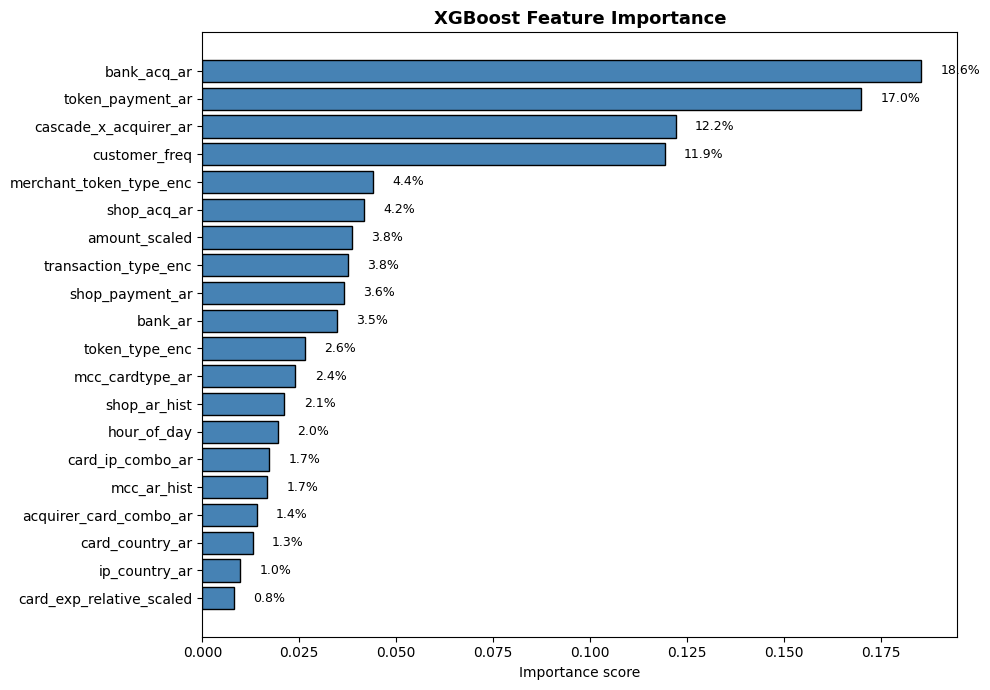


Feature importance:
  bank_acq_ar                         18.6%
  token_payment_ar                    17.0%
  cascade_x_acquirer_ar               12.2%
  customer_freq                       11.9%
  merchant_token_type_enc             4.4%
  shop_acq_ar                         4.2%
  amount_scaled                       3.8%
  transaction_type_enc                3.8%
  shop_payment_ar                     3.6%
  bank_ar                             3.5%
  token_type_enc                      2.6%
  mcc_cardtype_ar                     2.4%
  shop_ar_hist                        2.1%
  hour_of_day                         2.0%
  card_ip_combo_ar                    1.7%
  mcc_ar_hist                         1.7%
  acquirer_card_combo_ar              1.4%
  card_country_ar                     1.3%
  ip_country_ar                       1.0%
  card_exp_relative_scaled            0.8%


In [77]:
plot_feature_importance(val_model)


In [78]:
# ── Retrain on full train (no split) ─────────────────────────────────────
print("Retraining on full train data...")
full_stats = fit_stats(train, global_ar)
X_full     = build_features(train, full_stats)
y_full     = train['is_success'].astype(np.int8)

final_model = xgb.XGBClassifier(
    n_estimators     = best_n_trees,   # from early stopping above
    learning_rate    = 0.05,
    max_depth        = 6,
    min_child_weight = 100,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    n_jobs           = -1,
    random_state     = 42,
    verbosity        = 0,
)
final_model.fit(X_full, y_full, verbose=False)
print(f"  Trained {best_n_trees} trees on {len(train):,} rows.")

Retraining on full train data...
  Trained 500 trees on 6,005,849 rows.


In [79]:
# test_raw already loaded and enriched with temporal features in the temporal cell
X_test    = build_features(test_raw, full_stats)
test_prob = final_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= THRESHOLD).astype(int)

print(f"  Predicted approve rate : {test_pred.mean()*100:.2f}%")
print(f"  Train approve rate     : {global_ar*100:.2f}%")


  Test rows: 667,317
  Predicted approve rate : 53.80%
  Train approve rate     : 43.26%


In [80]:
submission = pd.DataFrame({
    'psp_order_id': test['psp_order_id'],
    'is_success':   test_pred,
})
submission.to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}  ({len(submission):,} rows)")
print(submission.head(5).to_string(index=False))

Saved: submission.csv  (667,317 rows)
           psp_order_id  is_success
1317034493699c1ac6898c5           1
1317034507699c1ac789bfa           0
1317034508699c1ac889de6           0
1317034508699c1ac98a2cd           0
1317034542699c1aca8a5b6           1


In [128]:
# ── Export feature matrices to CSV ────────────────────────────────────────
# Uses full_stats (fit on 100% train) — same stats used for final submission
print("Building feature matrices...")

# Train: features + target
X_full_df = pd.DataFrame(build_features(train, full_stats), columns=FEATURES)
X_full_df.insert(0, 'is_success', train['is_success'].values)
X_full_df.to_csv('data/train_features.csv', index=False)
print(f"  Saved train_features.csv  ({len(X_full_df):,} rows x {len(FEATURES)} features)")

# Test: features only (no target)
test_reload = pd.read_csv(TEST_PATH, low_memory=False)
test_reload['cascade_number'] = pd.to_numeric(test_reload['cascade_number'], errors='coerce')
X_test_df = pd.DataFrame(build_features(test_reload, full_stats), columns=FEATURES)
X_test_df.insert(0, 'psp_order_id', test_reload['psp_order_id'].values)
X_test_df.to_csv('data/test_features.csv', index=False)
print(f"  Saved test_features.csv   ({len(X_test_df):,} rows x {len(FEATURES)} features)")


Building feature matrices...
  Saved train_features.csv  (6,005,849 rows x 22 features)
  Saved test_features.csv   (667,317 rows x 22 features)
